In [1]:
import os
os.getcwd()

'/home/charles'

In [2]:
cd Project


/home/charles/Project


In [8]:
import pandas as pd
import numpy as np

In [11]:
file_df = pd.read_csv('final_dataset.csv')
file_df.head()

,compound,spacegroup,spacegroup_number,wyckoff_positions,atomic_species,number_of_atoms,cif_path,label
0,B1,Pnnm,58,"2d,4e,2b,8h,4f,4g,8h,4g,4g,8h,8h","['Ag', 'O', 'W']",56,cifs_linked/mp-504466.cif,Trivial
1,B1,R -3 m,166,"3b,1a,1a,1a","['Ag', 'Au', 'S']",6,cifs_linked/mp-34460.cif,Trivial
2,C1,Cmc 2 1,36,"4b,4b,4b,4b,4b,4b,4b,2a,4b,4b,2a,2a,2a,4b,4b,2...","['Ag', 'Br', 'Te']",68,cifs_linked/mp-568386.cif,Trivial
3,C1,R -3 m,166,"3b,1a,1a,1a","['Ag', 'Au', 'S']",6,cifs_linked/mp-34460.cif,Trivial
4,C1,Cmme,67,"2g,2g,4n","['Ag', 'Cl', 'O']",8,cifs_linked/mp-1079156.cif,TI


In [41]:
import pandas as pd
import numpy as np
import ast

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

In [27]:
import shap
import matplotlib.pyplot as plt

# For XGBoost later
from xgboost import XGBClassifier

shap.initjs()

In [28]:

df = pd.read_csv("final_dataset.csv")

print("Shape:", df.shape)
df.head()


Shape: (4341, 8)


,compound,spacegroup,spacegroup_number,wyckoff_positions,atomic_species,number_of_atoms,cif_path,label
0,B1,Pnnm,58,"2d,4e,2b,8h,4f,4g,8h,4g,4g,8h,8h","['Ag', 'O', 'W']",56,cifs_linked/mp-504466.cif,Trivial
1,B1,R -3 m,166,"3b,1a,1a,1a","['Ag', 'Au', 'S']",6,cifs_linked/mp-34460.cif,Trivial
2,C1,Cmc 2 1,36,"4b,4b,4b,4b,4b,4b,4b,2a,4b,4b,2a,2a,2a,4b,4b,2...","['Ag', 'Br', 'Te']",68,cifs_linked/mp-568386.cif,Trivial
3,C1,R -3 m,166,"3b,1a,1a,1a","['Ag', 'Au', 'S']",6,cifs_linked/mp-34460.cif,Trivial
4,C1,Cmme,67,"2g,2g,4n","['Ag', 'Cl', 'O']",8,cifs_linked/mp-1079156.cif,TI


In [39]:

df["label"] = df["label"].map({"Trivial": 0, "TI": 1})
print(df["label"].value_counts())


label
0    2190
1    2151
Name: count, dtype: int64


In [29]:

target_col = "label"   # change if needed

X = df.drop(columns=[target_col])
y = df[target_col]

print("Features:", X.shape[1])
print("Target distribution:\n", y.value_counts())


Features: 7
Target distribution:
 label
Trivial    2190
TI         2151
Name: count, dtype: int64


In [42]:
df["atomic_species"] = df["atomic_species"].apply(ast.literal_eval)

# Number of unique elements
df["n_elements"] = df["atomic_species"].apply(len)


In [43]:
features = [
    "spacegroup_number",
    "number_of_atoms",
    "n_elements"
]

X = df[features]
y = df["label"]

print(X.head())


   spacegroup_number  number_of_atoms  n_elements
0                 58               56           3
1                166                6           3
2                 36               68           3
3                166                6           3
4                 67                8           3


In [44]:

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=42,
    stratify=y   # ensures TI/Trivial balance
)


In [45]:

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp   # preserve balance again
)


In [46]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (2170, 3)
Validation: (1085, 3)
Test: (1086, 3)


In [47]:
def check_balance(name, y_data):
    print(f"\n{name} distribution:")
    print(y_data.value_counts(normalize=True))

check_balance("Train", y_train)
check_balance("Validation", y_val)
check_balance("Test", y_test)



Train distribution:
label
0    0.504608
1    0.495392
Name: proportion, dtype: float64

Validation distribution:
label
0    0.504147
1    0.495853
Name: proportion, dtype: float64

Test distribution:
label
0    0.504604
1    0.495396
Name: proportion, dtype: float64


In [54]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)


,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
print("Random Forest training complete.")


Random Forest training complete.


In [51]:

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report


In [52]:
def evaluate(model, X_data, y_true, name="Set"):
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:,1]

    print(f"\n{name} Performance")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print(classification_report(y_true, y_pred))

evaluate(rf, X_train, y_train, "Train")
evaluate(rf, X_val, y_val, "Validation")
evaluate(rf, X_test, y_test, "Test")



Train Performance
Accuracy: 0.7207373271889401
F1-score: 0.7396907216494846
ROC-AUC: 0.7956160135924393
              precision    recall  f1-score   support

           0       0.77      0.64      0.70      1095
           1       0.69      0.80      0.74      1075

    accuracy                           0.72      2170
   macro avg       0.73      0.72      0.72      2170
weighted avg       0.73      0.72      0.72      2170


Validation Performance
Accuracy: 0.6829493087557603
F1-score: 0.6977152899824253
ROC-AUC: 0.7553587326614247
              precision    recall  f1-score   support

           0       0.71      0.63      0.67       547
           1       0.66      0.74      0.70       538

    accuracy                           0.68      1085
   macro avg       0.69      0.68      0.68      1085
weighted avg       0.69      0.68      0.68      1085


Test Performance
Accuracy: 0.7007366482504604
F1-score: 0.7151621384750219
ROC-AUC: 0.7694031015114101
              precision    

In [55]:

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train)

# Check type
print(type(shap_values))
print(np.shape(shap_values))


<class 'numpy.ndarray'>
(2170, 3, 2)


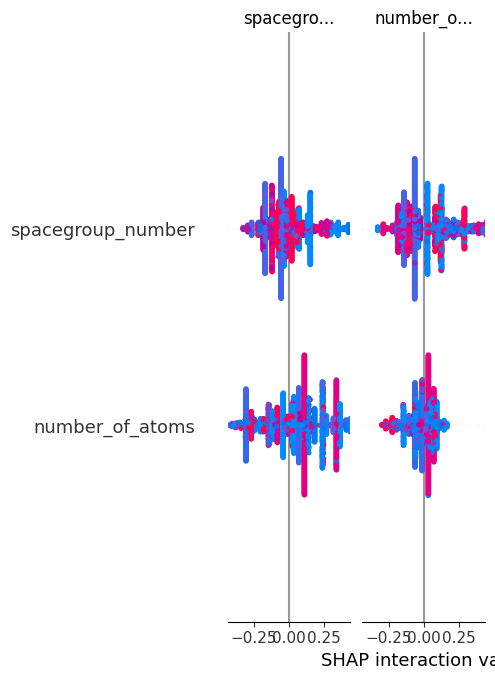

In [60]:
explainer = shap.TreeExplainer(rf)

# Compute SHAP values
shap_values = explainer(X_train)

# shap_values is an object with .values, .base_values, etc.
# Use .values for the summary plot
shap.summary_plot(shap_values.values, X_train, plot_type="bar")


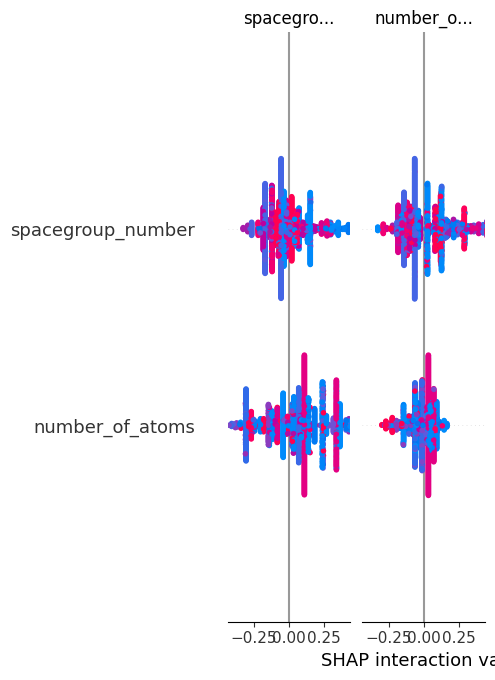

In [58]:
shap.summary_plot(shap_values, X_train, plot_type="bar")


(1, 3, 2)


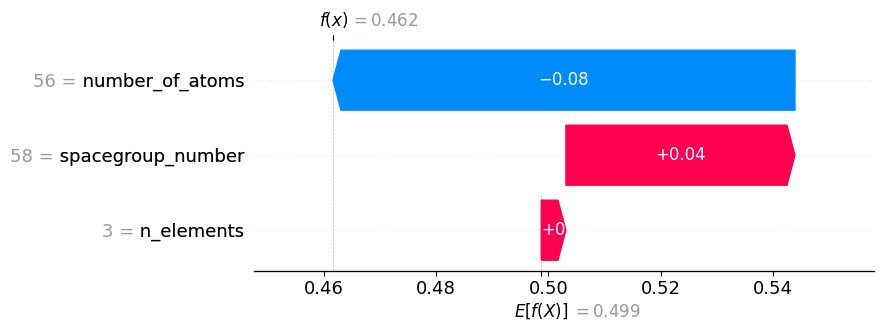

In [63]:
# Pick a single validation sample
sample = X_val.iloc[[0]]  # shape (1, n_features)

# Explain the sample
shap_values_sample = explainer(sample)

# Inspect the shape
print(shap_values_sample.values.shape)  # should show (1, n_features, 2) or (1, n_features)

# Waterfall for **class 1 (TI)** and single sample
shap.plots.waterfall(shap_values_sample[0][:,1])  # pick class 1


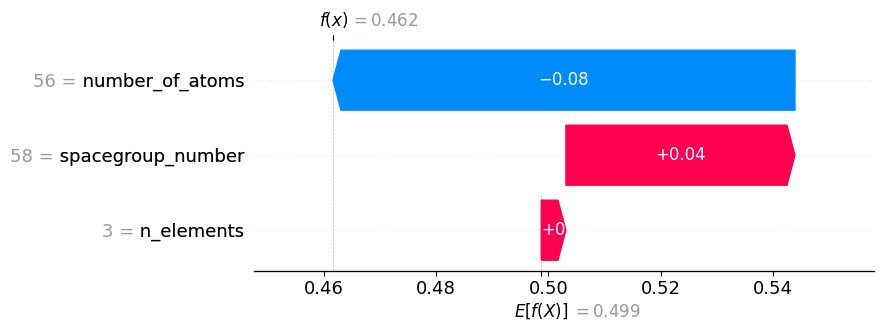

In [64]:
import shap

# Wrap into an Explanation object manually
expl = shap.Explanation(
    values=shap_values_sample.values[0][:,1],          # select first sample, class 1
    base_values=shap_values_sample.base_values[0][1],  # corresponding base value
    data=sample.iloc[0],
    feature_names=X_train.columns
)

shap.plots.waterfall(expl)


THE XGBOOst Model


In [65]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

print("XGBoost training complete.")


/home/charles/.local/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [15:10:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost training complete.


In [72]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

def evaluate(model, X_data, y_true, name="Set"):
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:,1]  # probability for class 1 (TI)

    print(f"\n{name} Performance")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print(classification_report(y_true, y_pred))


In [73]:
evaluate(xgb, X_train, y_train, "Train")
evaluate(xgb, X_val, y_val, "Validation")
evaluate(xgb, X_test, y_test, "Test")



Train Performance
Accuracy: 0.7207373271889401
F1-score: 0.7421276595744681
ROC-AUC: 0.7952481682064352
              precision    recall  f1-score   support

           0       0.77      0.63      0.70      1095
           1       0.68      0.81      0.74      1075

    accuracy                           0.72      2170
   macro avg       0.73      0.72      0.72      2170
weighted avg       0.73      0.72      0.72      2170


Validation Performance
Accuracy: 0.6866359447004609
F1-score: 0.7048611111111112
ROC-AUC: 0.7565429548126652
              precision    recall  f1-score   support

           0       0.72      0.62      0.67       547
           1       0.66      0.75      0.70       538

    accuracy                           0.69      1085
   macro avg       0.69      0.69      0.69      1085
weighted avg       0.69      0.69      0.69      1085


Test Performance
Accuracy: 0.7044198895027625
F1-score: 0.7211120764552563
ROC-AUC: 0.7693522236995631
              precision    

In [74]:
evaluate(xgb, X_train, y_train, "Train")
evaluate(xgb, X_val, y_val, "Validation")
evaluate(xgb, X_test, y_test, "Test")



Train Performance
Accuracy: 0.7207373271889401
F1-score: 0.7421276595744681
ROC-AUC: 0.7952481682064352
              precision    recall  f1-score   support

           0       0.77      0.63      0.70      1095
           1       0.68      0.81      0.74      1075

    accuracy                           0.72      2170
   macro avg       0.73      0.72      0.72      2170
weighted avg       0.73      0.72      0.72      2170


Validation Performance
Accuracy: 0.6866359447004609
F1-score: 0.7048611111111112
ROC-AUC: 0.7565429548126652
              precision    recall  f1-score   support

           0       0.72      0.62      0.67       547
           1       0.66      0.75      0.70       538

    accuracy                           0.69      1085
   macro avg       0.69      0.69      0.69      1085
weighted avg       0.69      0.69      0.69      1085


Test Performance
Accuracy: 0.7044198895027625
F1-score: 0.7211120764552563
ROC-AUC: 0.7693522236995631
              precision    

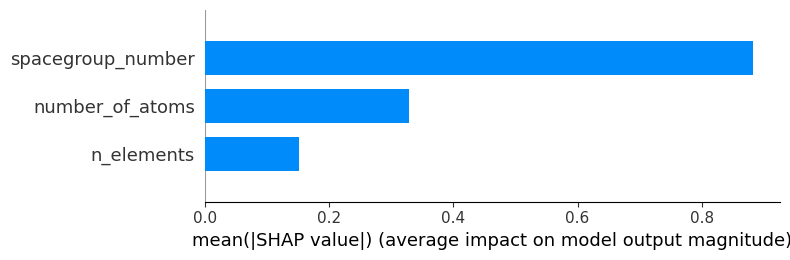

In [75]:
explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb(X_train)  # new SHAP API returns an Explanation object

# Summary bar plot (global feature importance)
shap.summary_plot(shap_values_xgb.values, X_train, plot_type="bar")


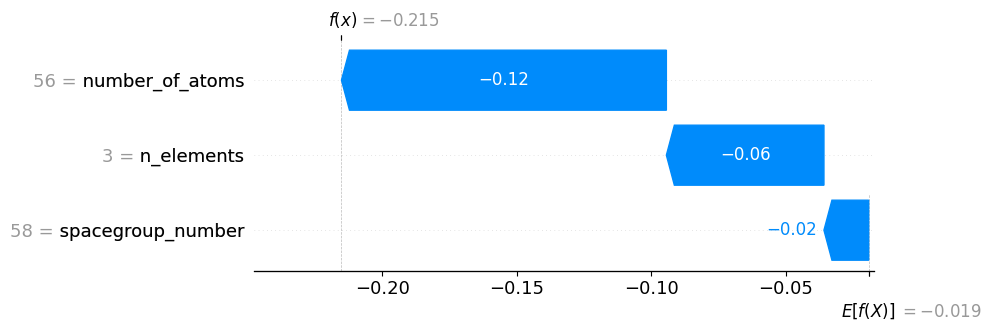

In [76]:
# Pick a sample from validation
sample = X_val.iloc[[0]]

shap_sample = explainer_xgb(sample)

# Waterfall for class 1 (TI)
shap.plots.waterfall(shap_sample[0])


In [77]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import shap


In [78]:
df = pd.read_csv("final_dataset.csv")

# Label encoding
df['label_num'] = df['label'].map({'Trivial':0,'TI':1})


In [79]:
atomic_data = {
    "H": {"Z": 1, "EN": 2.2}, "He": {"Z":2, "EN": 0}, "Li": {"Z":3, "EN":0.98}, 
    "Be": {"Z":4, "EN":1.57}, "B": {"Z":5, "EN":2.04}, "C": {"Z":6, "EN":2.55},
    "N": {"Z":7, "EN":3.04}, "O": {"Z":8, "EN":3.44}, "F": {"Z":9, "EN":3.98},
    "Na": {"Z":11, "EN":0.93}, "Mg": {"Z":12, "EN":1.31}, "Al": {"Z":13, "EN":1.61},
    "Si": {"Z":14, "EN":1.90}, "P": {"Z":15, "EN":2.19}, "S": {"Z":16, "EN":2.58},
    "Cl": {"Z":17, "EN":3.16}, "Ag": {"Z":47, "EN":1.93}, "Au": {"Z":79, "EN":2.54},
    "W": {"Z":74, "EN":2.36}, "Te":{"Z":52, "EN":2.1}, "Br":{"Z":35, "EN":2.96} 
}


In [81]:
def compute_atomic_features(species_list):
    # If species_list is string, convert to list
    if isinstance(species_list, str):
        species_list = eval(species_list)
    
    # Extract only known elements
    Z_list = [atomic_data[e]["Z"] for e in species_list if e in atomic_data]
    EN_list = [atomic_data[e]["EN"] for e in species_list if e in atomic_data]
    
    # If empty, fill with NaN
    if len(Z_list)==0:
        mean_Z = max_Z = min_Z = np.nan
        n_heavy = 0
    else:
        mean_Z = np.mean(Z_list)
        max_Z = np.max(Z_list)
        min_Z = np.min(Z_list)
        n_heavy = sum([1 for z in Z_list if z>50])
    
    if len(EN_list)==0:
        mean_EN = np.nan
    else:
        mean_EN = np.mean(EN_list)
    
    return pd.Series({
        "mean_Z": mean_Z,
        "max_Z": max_Z,
        "min_Z": min_Z,
        "mean_EN": mean_EN,
        "n_heavy": n_heavy
    })


In [82]:
atomic_features = df['atomic_species'].apply(compute_atomic_features)
atomic_features.fillna(atomic_features.mean(), inplace=True)


In [83]:
# Split 50/25/25
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.3333, stratify=y_temp, random_state=42
)

print("Train/Val/Test sizes:", X_train.shape[0], X_val.shape[0], X_test.shape[0])


Train/Val/Test sizes: 2170 1085 1086


In [84]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)


,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [85]:
def evaluate(model, X_data, y_true, name="Set"):
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:,1]
    print(f"\n{name} Performance")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print(classification_report(y_true, y_pred))


In [86]:
evaluate(rf, X_train, y_train, "Train")
evaluate(rf, X_val, y_val, "Validation")
evaluate(rf, X_test, y_test, "Test")



Train Performance
Accuracy: 0.7216589861751153
F1-score: 0.7343887423043096
ROC-AUC: 0.7968992248062016
              precision    recall  f1-score   support

           0       0.75      0.67      0.71      1095
           1       0.70      0.78      0.73      1075

    accuracy                           0.72      2170
   macro avg       0.72      0.72      0.72      2170
weighted avg       0.72      0.72      0.72      2170


Validation Performance
Accuracy: 0.6995391705069124
F1-score: 0.7140350877192982
ROC-AUC: 0.7681201280387107
              precision    recall  f1-score   support

           0       0.73      0.64      0.68       547
           1       0.68      0.76      0.71       538

    accuracy                           0.70      1085
   macro avg       0.70      0.70      0.70      1085
weighted avg       0.70      0.70      0.70      1085


Test Performance
Accuracy: 0.6860036832412523
F1-score: 0.6952636282394995
ROC-AUC: 0.756802363443953
              precision    r

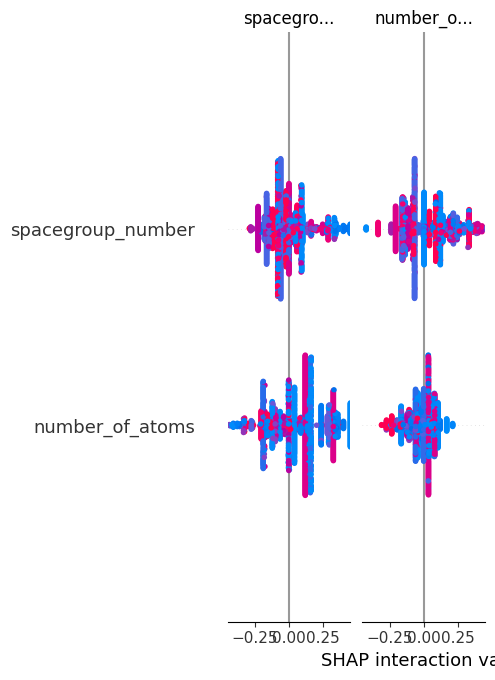

In [87]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_train)

# Summary bar plot
shap.summary_plot(shap_values.values, X_train, plot_type="bar")


In [89]:
# 1️⃣ Atomic features
def compute_atomic_features(species_list):
    # Convert string to list if needed
    if isinstance(species_list, str):
        species_list = eval(species_list)

    # Extract known elements
    Z_list = [atomic_data[e]["Z"] for e in species_list if e in atomic_data]
    EN_list = [atomic_data[e]["EN"] for e in species_list if e in atomic_data]
    
    # Handle empty lists safely
    if len(Z_list)==0:
        mean_Z = max_Z = min_Z = np.nan
        n_heavy = 0
    else:
        mean_Z = np.mean(Z_list)
        max_Z = np.max(Z_list)
        min_Z = np.min(Z_list)
        n_heavy = sum([1 for z in Z_list if z>50])
    
    if len(EN_list)==0:
        mean_EN = np.nan
    else:
        mean_EN = np.mean(EN_list)
    
    return pd.Series({
        "mean_Z": mean_Z,
        "max_Z": max_Z,
        "min_Z": min_Z,
        "mean_EN": mean_EN,
        "n_heavy": n_heavy
    })

# Apply to atomic_species column
atomic_features = df['atomic_species'].apply(compute_atomic_features)

# Fill NaN with column mean
atomic_features.fillna(atomic_features.mean(), inplace=True)

# 2️⃣ Wyckoff features
def wyckoff_features(wyckoff_str):
    if not isinstance(wyckoff_str, str):
        return pd.Series({"n_positions":0, "n_unique_letters":0, "sum_multiplicities":0})
    
    letters = [c for c in wyckoff_str if c.isalpha()]
    numbers = [int(c) for c in wyckoff_str if c.isdigit()]
    
    return pd.Series({
        "n_positions": len(letters),
        "n_unique_letters": len(set(letters)),
        "sum_multiplicities": sum(numbers) if numbers else 0
    })

wyckoff_feats = df['wyckoff_positions'].apply(wyckoff_features)

# 3️⃣ Combine all numeric features
X = pd.concat([
    df[['spacegroup_number', 'number_of_atoms']], 
    atomic_features, 
    wyckoff_feats
], axis=1)

# Target
y = df['label_num']

print("Feature matrix shape:", X.shape)



Feature matrix shape: (4341, 10)


In [90]:
from sklearn.model_selection import train_test_split

# Split dataset 50/25/25 with stratification for balanced classes
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.3333, stratify=y_temp, random_state=42
)

print("Train / Validation / Test sizes:", X_train.shape[0], X_val.shape[0], X_test.shape[0])


Train / Validation / Test sizes: 2170 1085 1086


In [91]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
print("Random Forest trained successfully.")


Random Forest trained successfully.


In [92]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

def evaluate(model, X_data, y_true, name="Set"):
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:,1]  # probability for class 1 (TI)

    print(f"\n{name} Performance")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print(classification_report(y_true, y_pred))


In [93]:
evaluate(rf, X_train, y_train, "Train")
evaluate(rf, X_val, y_val, "Validation")
evaluate(rf, X_test, y_test, "Test")




Train Performance
Accuracy: 0.7216589861751153
F1-score: 0.7343887423043096
ROC-AUC: 0.7969085696081555
              precision    recall  f1-score   support

           0       0.75      0.67      0.71      1095
           1       0.70      0.78      0.73      1075

    accuracy                           0.72      2170
   macro avg       0.72      0.72      0.72      2170
weighted avg       0.72      0.72      0.72      2170


Validation Performance
Accuracy: 0.7004608294930875
F1-score: 0.7151621384750219
ROC-AUC: 0.769503136404722
              precision    recall  f1-score   support

           0       0.73      0.64      0.68       547
           1       0.68      0.76      0.72       538

    accuracy                           0.70      1085
   macro avg       0.70      0.70      0.70      1085
weighted avg       0.70      0.70      0.70      1085


Test Performance
Accuracy: 0.6841620626151013
F1-score: 0.6940231935771632
ROC-AUC: 0.7568108430792609
              precision    r

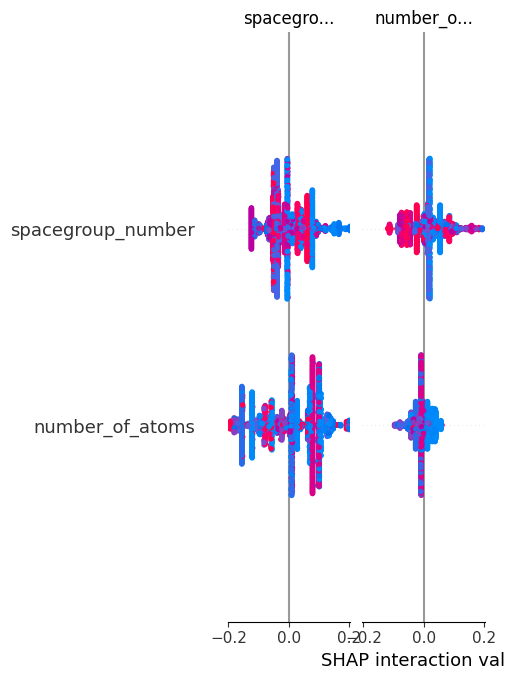

In [94]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_train)

# SHAP summary bar plot
shap.summary_plot(shap_values.values, X_train, plot_type="bar")


(1, 10, 2)


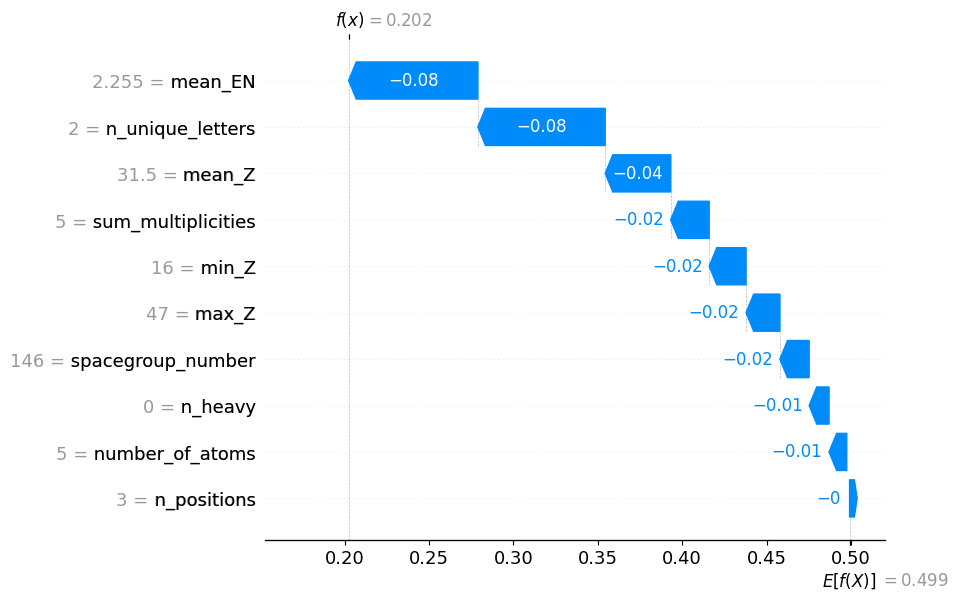

In [96]:
# Pick a single validation sample
sample = X_val.iloc[[0]]  # shape (1, n_features)

# Explain the sample
shap_values_sample = explainer(sample)

# Inspect the shape
print(shap_values_sample.values.shape)  # should show (1, n_features, 2) or (1, n_features)

# Waterfall for **class 1 (TI)** and single sample
shap.plots.waterfall(shap_values_sample[0][:,1])  # pick class 1


In [100]:
import xgboost as xgb


In [102]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),  # balance classes
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'  # needed to avoid warning in old versions
)

# Fit model
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

print("XGBoost trained successfully.")


/home/charles/.local/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [15:37:39] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-logloss:0.68607
[1]	validation_0-logloss:0.67794
[2]	validation_0-logloss:0.67071
[3]	validation_0-logloss:0.66365
[4]	validation_0-logloss:0.65679
[5]	validation_0-logloss:0.65236
[6]	validation_0-logloss:0.64675
[7]	validation_0-logloss:0.64192
[8]	validation_0-logloss:0.63719
[9]	validation_0-logloss:0.63431
[10]	validation_0-logloss:0.62974
[11]	validation_0-logloss:0.62601
[12]	validation_0-logloss:0.62271
[13]	validation_0-logloss:0.61997
[14]	validation_0-logloss:0.61671
[15]	validation_0-logloss:0.61398
[16]	validation_0-logloss:0.61222
[17]	validation_0-logloss:0.60906
[18]	validation_0-logloss:0.60705
[19]	validation_0-logloss:0.60460
[20]	validation_0-logloss:0.60204
[21]	validation_0-logloss:0.60009
[22]	validation_0-logloss:0.59844
[23]	validation_0-logloss:0.59650
[24]	validation_0-logloss:0.59524
[25]	validation_0-logloss:0.59327
[26]	validation_0-logloss:0.59198
[27]	validation_0-logloss:0.59091
[28]	validation_0-logloss:0.58913
[29]	validation_0-loglos

In [104]:
evaluate(xgb_model, X_train, y_train, "Train")
evaluate(xgb_model, X_val, y_val, "Validation")
evaluate(xgb_model, X_test, y_test, "Test")



Train Performance
Accuracy: 0.7216589861751153
F1-score: 0.7405498281786942
ROC-AUC: 0.7969060210258044
              precision    recall  f1-score   support

           0       0.77      0.64      0.70      1095
           1       0.69      0.80      0.74      1075

    accuracy                           0.72      2170
   macro avg       0.73      0.72      0.72      2170
weighted avg       0.73      0.72      0.72      2170


Validation Performance
Accuracy: 0.6986175115207374
F1-score: 0.7207514944491887
ROC-AUC: 0.7719395418062702
              precision    recall  f1-score   support

           0       0.74      0.61      0.67       547
           1       0.67      0.78      0.72       538

    accuracy                           0.70      1085
   macro avg       0.71      0.70      0.70      1085
weighted avg       0.71      0.70      0.70      1085


Test Performance
Accuracy: 0.6887661141804788
F1-score: 0.7076124567474048
ROC-AUC: 0.7575740102569669
              precision    

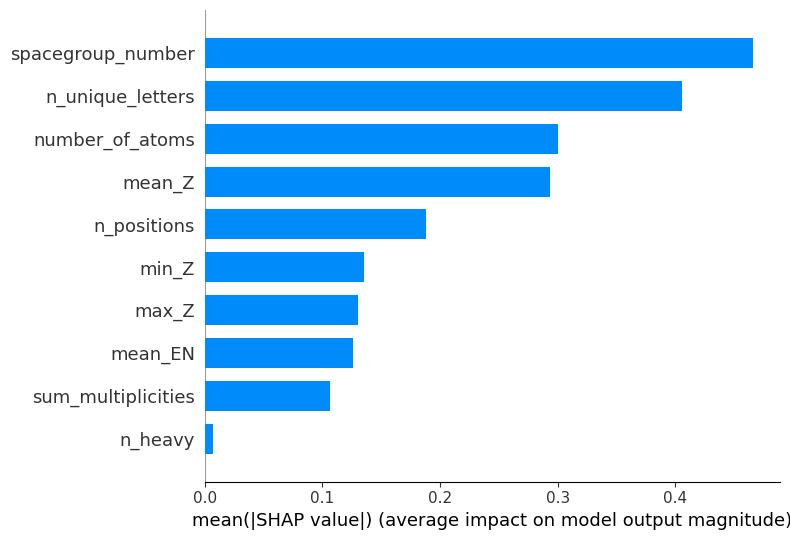

In [105]:
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb(X_train)

# Global feature importance
shap.summary_plot(shap_values_xgb.values, X_train, plot_type="bar")


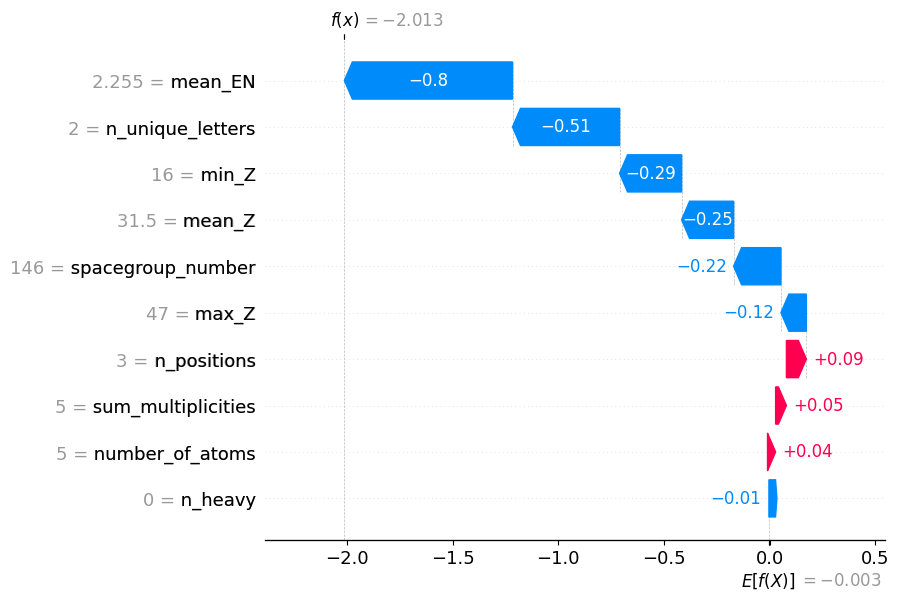

In [106]:
# Pick one validation sample
sample_xgb = X_val.iloc[[0]]
shap_sample_xgb = explainer_xgb(sample_xgb)

# Waterfall plot
shap.plots.waterfall(shap_sample_xgb[0])


In [107]:
pip install maggma pymatgen megnet


Defaulting to user installation because normal site-packages is not writeable
  Using cached mongomock-4.3.0-py2.py3-none-any.whl.metadata (12 kB)
  Using cached jsonlines-4.0.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached aioitertools-0.13.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sshtunnel-0.4.0-py2.py3-none-any.whl.metadata (19 kB)
  Using cached sentinels-1.1.1-py3-none-any.whl.metadata (3.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 5.1 MB/s  0:00:004.0 MB/s eta 0:00:01
Using cached aioitertools-0.13.0-py3-none-any.whl (24 kB)
Using cached jsonlines-4.0.0-py3-none-any.whl (8.7 kB)
Using cached mongomock-4.3.0-py2.py3-none-any.whl (64 kB)
Using cached sshtunnel-0.4.0-py2.py3-none-any.whl (24 kB)
Using cached sentinels-1.1.1-py3-none-any.whl (3.7 kB)
  Attempting uninstall: pymongo
    Found existing installation: pymongo 4.15.4
    Uninstalling pymongo-4.15.4:
      Successfully uninstalled pymongo-4.15.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/

In [110]:
pip install tensorflow


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.8/620.8 MB 25.4 MB/s  0:00:23 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 26.7 MB/s  0:00:009.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 23.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 24.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 24.9 MB/s  0:00:00 29.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 25.8 MB/s  0:00:008.8 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17/17 [tensorflow]37m━━ 16/17 [tensorflow]]]ver]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [111]:
from megnet.data.crystal import CrystalGraph
from pymatgen.core import Structure
import pandas as pd


2026-02-16 15:44:56.538803: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-16 15:44:57.080505: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-16 15:45:03.411478: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
